In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [2]:
# Download Google stock data (GOOG)
print("Downloading stock data...")
data = yf.download('GOOG', start='2018-01-01', end='2024-01-01')

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
# Use only 'Close' column
data_close = data[['Close']]

In [4]:
# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_close)

In [5]:
# Function to create sequences
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(seq_length, len(data)):
        x.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

In [6]:
# Sequence length (60 days)
sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

In [7]:
# Reshape input for RNN
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [8]:
# Train-Test Split (80% training, 20% testing)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [9]:
# Build RNN model
model = Sequential([
    SimpleRNN(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

C:\Users\pawar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Show model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train model
print("Training the model...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Training the model...
Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0413 - val_loss: 0.0019
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.9490e-04 - val_loss: 0.0014
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.1436e-04 - val_loss: 0.0014
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.8871e-04 - val_loss: 0.0014
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.5435e-04 - val_loss: 0.0013
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.1408e-04 - val_loss: 0.0012
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.7811e-04 - val_loss: 0.0012
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.5503e-04 - val_loss: 0.0012
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.6745e-04 - val_loss: 0.0012
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6952e-04 - val_loss: 0.0011
Epoch 12/20
37/

In [13]:
# Predict stock prices
print("Predicting stock prices...")
predicted_stock_price = model.predict(X_test)

Predicting stock prices...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 


In [14]:
# Convert back to original scale
predicted_stock_price = scaler.inverse_transform(predicted_stock_price.reshape(-1, 1))
real_stock_price = scaler.inverse_transform(y_test.reshape(-1, 1))

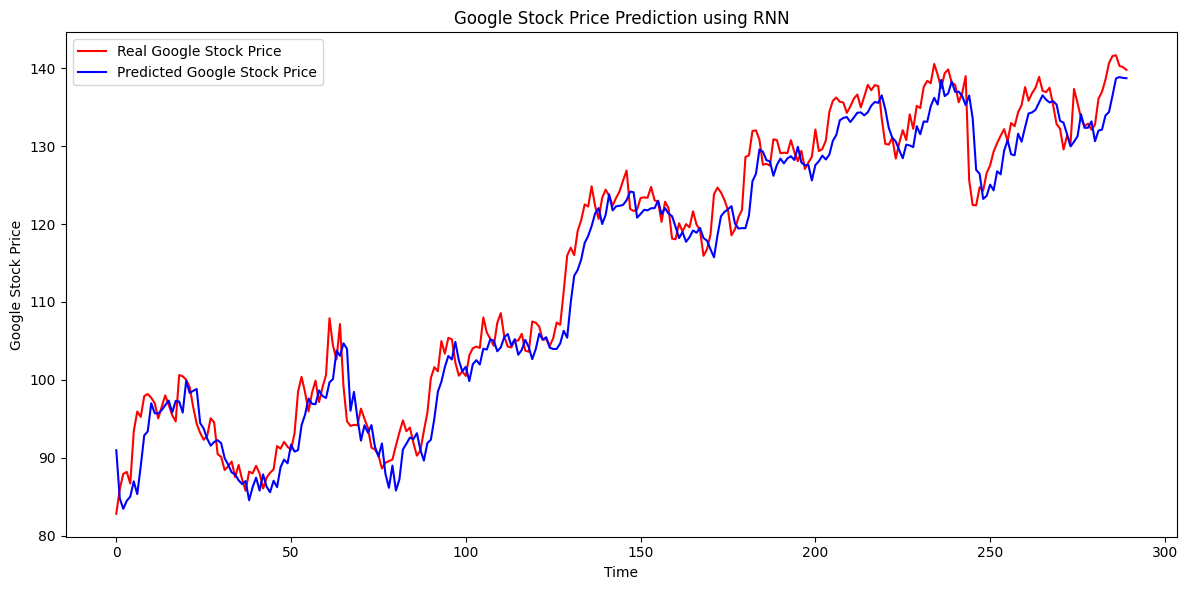

In [15]:
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction using RNN')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.tight_layout()
plt.show()